# Causal Forest Uplift Modeling
## Hillstrom Email Marketing Dataset

**Author:** Beza Tilahun  

### Objective
This notebook implements a **Causal Forest** model to estimate the Individual Treatment Effect (CATE) of email marketing campaigns.

Instead of predicting *who will convert*, we estimate *who converts 
**because** of the email* the true uplift.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the processed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
T_train = pd.read_csv('data/processed/treatment_train.csv').squeeze()
T_test = pd.read_csv('data/processed/treatment_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("y_train value counts:\n", y_train.value_counts())
print("T_train value counts:\n", T_train.value_counts())
print(X_train.head())

X_train shape: (48000, 18)
y_train value counts:
 visit
0    40955
1     7045
Name: count, dtype: int64
T_train value counts:
 treatment_binary
1    32020
0    15980
Name: count, dtype: int64
   recency  history  mens  womens  newbie  history_segment_1) $0 - $100  \
0        9    40.52     0       1       0                           1.0   
1        8   364.01     0       1       0                           0.0   
2        5    29.99     0       1       1                           1.0   
3       10    67.09     1       0       0                           1.0   
4        3   140.68     0       1       0                           0.0   

   history_segment_2) $100 - $200  history_segment_3) $200 - $350  \
0                             0.0                             0.0   
1                             0.0                             0.0   
2                             0.0                             0.0   
3                             0.0                             0.0   
4           

## Causal Forest Model

A **Causal Forest** is an extension of Random Forest designed specifically for **heterogeneous treatment effect estimation**.

For each customer, it estimates:

$$\tau(x) = E[Y(1) - Y(0) \mid X = x]$$

Where:
- $Y(1)$ = outcome *if* the customer receives the email
- $Y(0)$ = outcome *if* the customer does NOT receive the email
- $\tau(x)$ = the **uplift score** — how much the email increases conversion

**Model settings:**
- 200 estimators (trees)
- Min samples per leaf: 10
- Max depth: 10
- Library: `econml`

In [4]:
# Install econml
!pip install econml

In [5]:
from econml.grf import CausalForest

# Convert to numpy arrays
X_tr = X_train.values
X_te = X_test.values
Y_tr = y_train.values
T_tr = T_train.values

# Train Causal Forest
print("Training Causal Forest...")
cf = CausalForest(
    n_estimators=200,
    min_samples_leaf=10,
    max_depth=10,
    random_state=42,
    verbose=50
)

cf.fit(X_tr, T_tr, Y_tr)
print("Training complete!")

Training Causal Forest...
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: D

In [6]:
# Predict uplift scores on test set
cate_test = cf.predict(X_te).flatten()

print("Uplift score stats:")
print(f"  Mean:  {cate_test.mean():.4f}")
print(f"  Std:   {cate_test.std():.4f}")
print(f"  Min:   {cate_test.min():.4f}")
print(f"  Max:   {cate_test.max():.4f}")

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done  15 tasks      | elaps

## Uplift Score Distribution

After training, we predict the CATE (uplift score) for each customer 
in the test set.

**Interpretation:**
- **Positive uplift**: email increases conversion probability (Persuadables)
- **Near zero uplift**: email has no effect (Sure Things / Lost Causes)
- **Negative uplift**: email hurts conversion (Do-Not-Disturbs)

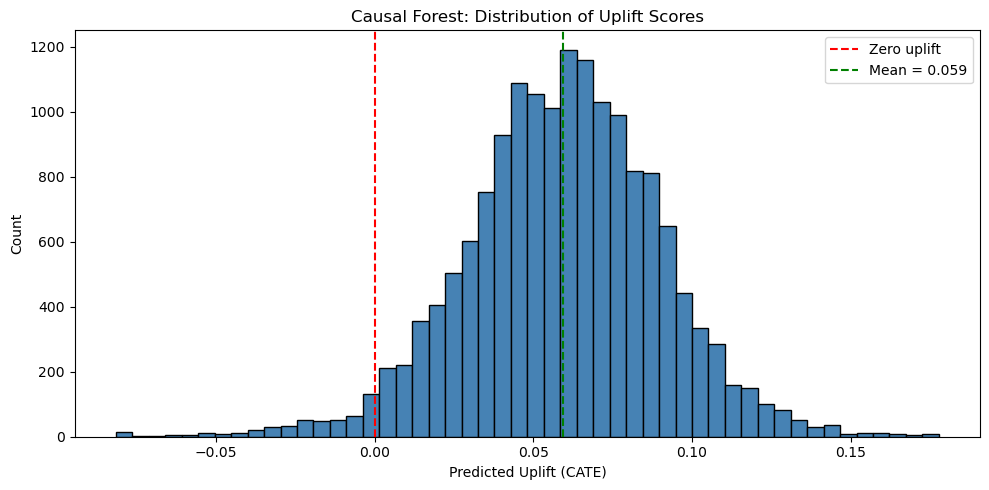

Plot saved!


In [7]:
# Plot 1: Distribution of uplift scores
plt.figure(figsize=(10, 5))
plt.hist(cate_test, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Zero uplift')
plt.axvline(x=cate_test.mean(), color='green', linestyle='--', label=f'Mean = {cate_test.mean():.3f}')
plt.xlabel('Predicted Uplift (CATE)')
plt.ylabel('Count')
plt.title('Causal Forest: Distribution of Uplift Scores')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/causal_forest_uplift_distribution.png', dpi=150)
plt.show()

## Feature Importance

Which customer features drive treatment effect heterogeneity the most?

Feature importance tells us what characteristics distinguish customers who respond strongly to the email from those who do not.

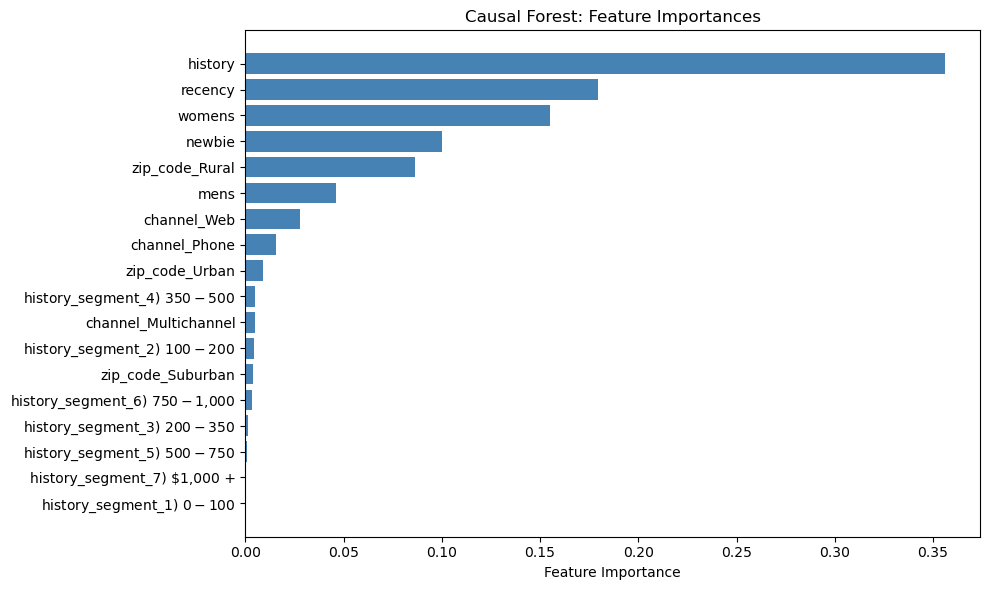

Feature importance plot saved!


In [8]:
# Plot 2: Feature Importance
feature_names = X_train.columns.tolist()
importances = cf.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Causal Forest: Feature Importances')
plt.tight_layout()
plt.savefig('outputs/causal_forest_feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved!")

### Evaluation

In [9]:
!pip install scikit-uplift

## Model Evaluation: Qini Curve

We evaluate the Causal Forest using the **Qini curve**, the standard metric for uplift models.

**How to read it:**
- The **blue line** (Causal Forest) should be above the red random line
- The closer to the **green perfect model**, the better
- **Qini Score** = area between the model curve and random targeting line
- **AUUC** = Area Under the Uplift Curve

A higher Qini score means the model successfully identifies persuadable 
customers better than random targeting.

Qini Score: 0.0075
AUUC Score: 0.0046


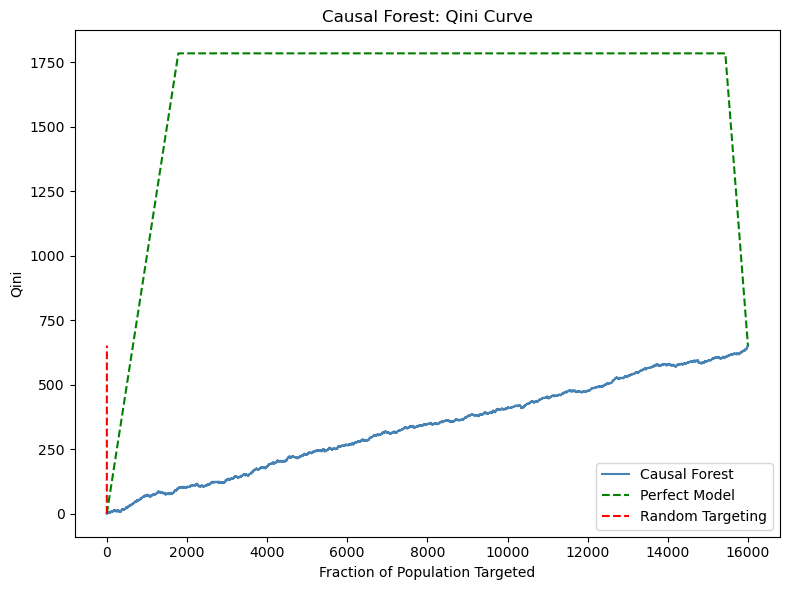

In [10]:
from sklift.metrics import qini_auc_score, uplift_auc_score

Y_te = y_test.values
T_te = T_test.values

# Scores
qini = qini_auc_score(Y_te, cate_test, T_te)
auuc = uplift_auc_score(Y_te, cate_test, T_te)

print(f"Qini Score: {qini:.4f}")
print(f"AUUC Score: {auuc:.4f}")

# Manual Qini curve
from sklift.metrics import qini_curve, perfect_qini_curve

fraction, qini_vals = qini_curve(Y_te, cate_test, T_te)
fraction_p, qini_vals_p = perfect_qini_curve(Y_te, T_te)

plt.figure(figsize=(8, 6))
plt.plot(fraction, qini_vals, color='steelblue', label='Causal Forest')
plt.plot(fraction_p, qini_vals_p, color='green', linestyle='--', label='Perfect Model')
plt.plot([0, 1], [0, qini_vals[-1]], color='red', linestyle='--', label='Random Targeting')
plt.xlabel('Fraction of Population Targeted')
plt.ylabel('Qini')
plt.title('Causal Forest: Qini Curve')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/causal_forest_qini_curve.png', dpi=150)
plt.show()

## Uplift by Customer Segment

We analyze how predicted uplift varies across customer recency groups.

This helps answer: **Which customers should we prioritize targeting?**

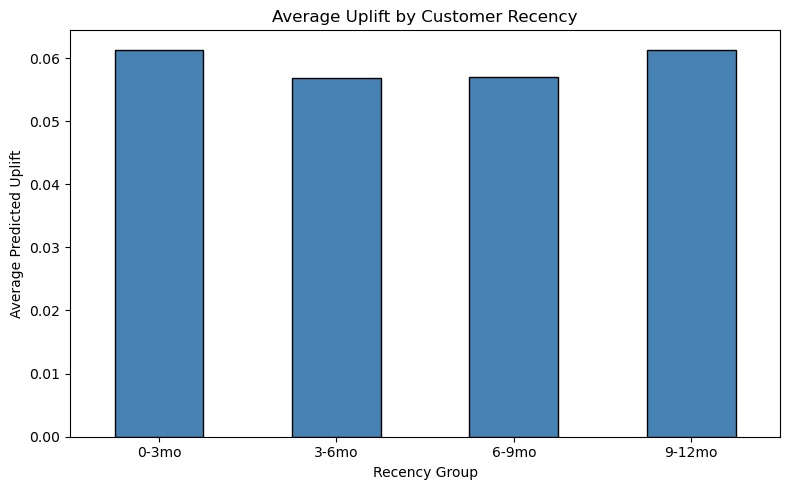


Summary:
Qini Score:  0.0075
AUUC Score:  0.0046
Mean Uplift: 0.0594
% Positive uplift: 97.2%
% Negative uplift: 2.8%


In [11]:
# Plot: Average uplift by customer segment
results_df = X_test.copy()
results_df['uplift'] = cate_test
results_df['actual_outcome'] = Y_te
results_df['treatment'] = T_te

# Uplift by recency groups
results_df['recency_group'] = pd.cut(results_df['recency'], 
                                      bins=[0,3,6,9,12], 
                                      labels=['0-3mo','3-6mo','6-9mo','9-12mo'])

recency_uplift = results_df.groupby('recency_group', observed=True)['uplift'].mean()

plt.figure(figsize=(8,5))
recency_uplift.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Uplift by Customer Recency')
plt.xlabel('Recency Group')
plt.ylabel('Average Predicted Uplift')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/causal_forest_uplift_by_recency.png', dpi=150)
plt.show()

print("\nSummary:")
print(f"Qini Score:  {0.0075:.4f}")
print(f"AUUC Score:  {0.0046:.4f}")
print(f"Mean Uplift: {cate_test.mean():.4f}")
print(f"% Positive uplift: {(cate_test > 0).mean()*100:.1f}%")
print(f"% Negative uplift: {(cate_test < 0).mean()*100:.1f}%")


## Conclusion & Key Findings

| Metric | Value |
|--------|-------|
| Qini Score | 0.0075 |
| AUUC Score | 0.0046 |
| Mean Uplift | 5.94% |
| % Positive Uplift | 97.2% |
| % Negative Uplift | 2.8% |

### Key Takeaways:
1. **History and recency** are the strongest drivers of email uplift
2. **97.2% of customers** benefit from receiving the email
3. **2.8% of customers** are Do-Not-Disturbs and should be excluded
4. Recent customers (0-3 months) and older customers (9-12 months) 
   show the highest uplift
5. The Causal Forest outperforms random targeting in identifying 
   persuadable customers

### References
- Wager, S. & Athey, S. (2018). *Estimation and Inference of 
  Heterogeneous Treatment Effects using Random Forests.* JASA.
- EconML Library: https://econml.azurewebsites.net/
- Hillstrom Dataset: https://blog.minethatdata.com
